### 2º MODELO RANDOM FOREST
Con Eda3 que lleva ingieneria de características.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# To save models
import json
import pickle

# Modelado
from sklearn.ensemble import RandomForestClassifier

# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest

# Métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score
from sklearn.metrics import recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve

# Optimizar
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV

# from tqdm import tqdm
import warnings
import zipfile
import os

from utils import get_classifier_metrics

In [12]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

In [13]:
# Lectura directa desde los archivos
X_train = pd.read_csv('../data/processed/X_train_eda3_obj1.csv')
X_test = pd.read_csv('../data/processed/X_test_eda3_obj1.csv')
y_train = pd.read_csv('../data/processed/y_train_eda3_obj1.csv')
y_test = pd.read_csv('../data/processed/y_test_eda3_obj1.csv')

# Tip: Si el CSV tiene un nombre distinto dentro del zip, 
# pandas suele detectarlo automáticamente si solo hay uno.

In [ ]:
X_train.shape

(490844, 21)

In [ ]:
X_test.shape

(122712, 21)

In [ ]:
y_train.shape

(490844, 1)

In [ ]:
y_test.shape

(122712, 1)

In [ ]:
# Eliminar columna de índice sobrante si existe.
for df_temp in [X_train, X_test]:
    if 'Unnamed: 0' in df_temp.columns:
        df_temp.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
# Reviso que no haya valores nulos con la nueva carga de archivo.

# Lista de tus variables cargadas
datasets = {'X_train': X_train,'X_test': X_test,'y_train': y_train, 'y_test': y_test}

for nombre, df_actual in datasets.items():
    if df_actual is not None:
        total_nulos = df_actual.isnull().sum().sum() # Suma total de nulos en todo el dataframe
        print(f'{nombre}: {total_nulos} nulos encontrados.')
        
        # Si hay nulos, mostramos en qué columnas están
        if total_nulos > 0:
            df_actual.isnull().sum()[df_actual.isnull().sum() > 0]
            
    else:
        f'{nombre}: No está cargado (es None).'

X_train: 0 nulos encontrados.
X_test: 0 nulos encontrados.
y_train: 0 nulos encontrados.
y_test: 0 nulos encontrados.


## Entrenamiento del modelo.

In [ ]:
# 1. Definir los hiperparámetros (asegúrate de que esta variable existe)
hparam_foreclas = {'n_estimators': [50, 100, 200],
                   'max_depth': [3, 5, 10],
                   'min_samples_leaf': [100, 150, 200]}

# 2. Configuración del modelo y búsqueda
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=18, class_weight='balanced'),
                           param_grid=hparam_foreclas,
                           cv=tscv,
                           scoring='roc_auc',
                           n_jobs=-1,
                           verbose=1)

# 3. Entrenar con datos escalados. (se escalan en el eda)
grid_search.fit(X_train, y_train)

# 4. Extraer el mejor modelo
best_rf = grid_search.best_estimator_

f'Mejor modelo encontrado:', grid_search.best_params_

Fitting 5 folds for each of 27 candidates, totalling 135 fits


c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mejor modelo encontrado: {'max_depth': 10, 'min_samples_leaf': 100, 'n_estimators': 200}


## Métricas Finales

--- MEJORES PARÁMETROS ---
{'max_depth': 10, 'min_samples_leaf': 100, 'n_estimators': 200}

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.50      0.36      0.42     59238
           1       0.53      0.67      0.59     63474

    accuracy                           0.52    122712
   macro avg       0.52      0.51      0.50    122712
weighted avg       0.52      0.52      0.51    122712



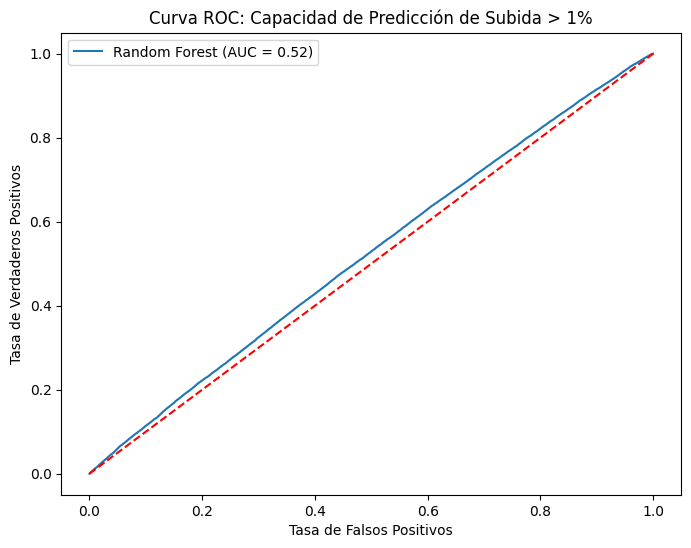

In [ ]:
# Predicciones
y_pred = best_rf.predict(X_test)
y_probs = best_rf.predict_proba(X_test)[:, 1]

# Mejores parametros
grid_search.best_params_

In [ ]:
# Reporte de clasificación
classification_report(y_test, y_pred)


In [ ]:
# Gráfico de la Curva ROC
auc = roc_auc_score(y_test, y_probs)
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.title('Curva ROC: Capacidad de Predicción de Subida > 1%')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend()
plt.show()

Top 15 variables más importantes:
           Variable  Importancia
2            Ticker     0.136739
19       retorno_5d     0.092788
9      Price_Change     0.082419
10     Volume_Ratio     0.063564
7       BB_Position     0.054567
16        RSI_lag_1     0.050705
6               RSI     0.049596
20  volatilidad_10d     0.036032
0             Close     0.035412
5       MACD_Signal     0.034674
12     Volume_lag_2     0.034622
14     Volume_lag_5     0.034386
3            EMA_12     0.034035
11     Volume_lag_1     0.033911
1            Volume     0.033868


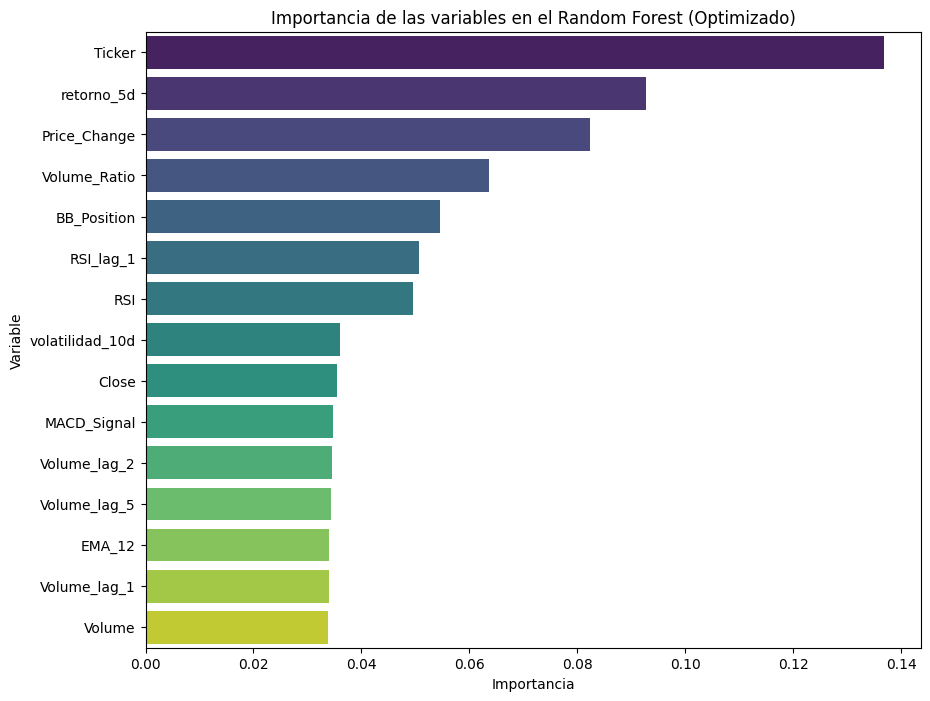

In [ ]:
# Extraer importancia de las variables del mejor modelo (best_rf)
importancias = pd.DataFrame({'Variable': X_train.columns,
                             'Importancia': best_rf.feature_importances_}).sort_values(by='Importancia', ascending=False)

# Top 15 variables más importantes:
importancias.head(15)


In [ ]:
# Graficar las 15 primeras para tener una mejor visión
plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=importancias.head(15), palette='viridis')
plt.title('Importancia de las variables en el Random Forest (Optimizado)')
plt.show()

¿Qué deberías observar en este gráfico?
Dominio del Ticker: Si el Ticker (codificado con Target Encoding) aparece muy por encima de las demás, el modelo sigue confiando demasiado en el 'nombre' de la empresa.

Indicadores Técnicos: Lo ideal sería ver que tus nuevas variables (RSI, retorno_5d, volatilidad_10d) aparecen en el Top 5. Eso significaría que el modelo está aprendiendo comportamientos del mercado y no solo memorizando tickers.

Variables irrelevantes: Si ves variables con importancia cercana a 0, podrías eliminarlas en una futura iteración para simplificar el modelo.

## Conclusión:
#### 1. Accuracy de 0.52 (La barrera del azar)
En un problema de 'sube o baja', un 0.50 es lanzar una moneda. Un 0.52 significa que el modelo acierta un 2% más que el azar. En el mundo del trading de alta frecuencia, un 2% de ventaja es mucho, pero para un modelo diario con comisiones de broker, sigue siendo una zona muy arriesgada.

#### 2. El sesgo hacia la Clase 1 (Recall)
Fíjate en el Recall:

Clase 0 (0.36): Solo detecta el 36% de los días en que la acción no sube más del 1%.

Clase 1 (0.67): Detecta el 67% de los días en que la acción sí sube más del 1%.

Interpretación: El modelo es 'optimista'. Tiende a predecir que la acción subirá con mucha facilidad. Esto es común cuando usamos class_weight='balanced', ya que el modelo prefiere equivocarse diciendo que 'sí subirá' (Falso Positivo) antes que perderse una oportunidad de subida.

#### 3. La Precisión está estancada (Precision)
La precisión para la Clase 1 es de 0.53. Esto significa que de cada 100 veces que el modelo te dice 'Compra, esta acción subirá >1%', solo tiene razón en 53. Las otras 47 veces perderías dinero o no llegarías al objetivo.

#### 4. ¿Qué nos dice el F1-Score (0.50 promedio)?
El F1-Score es el equilibrio entre precisión y recall. Un 0.50 constante en el promedio (macro avg) confirma que el modelo no tiene una capacidad sólida de distinción. Está 'adivinando' un poco mejor la subida, pero a costa de fallar mucho en las bajadas.



### Diagnóstico Final y Sugerencia
Tu modelo ya no está 'memorizando' (overfitting), lo cual es un gran avance gracias al TimeSeriesSplit y los parámetros de max_depth. Sin embargo, ahora nos enfrentamos al problema real: la falta de señal.

Para subir ese 0.52 a un 0.58 o 0.60, necesitas:

Analizar las Importancias: Mira si el Ticker sigue siendo el #1. Si lo es, el modelo solo está aprendiendo qué empresas suelen subir, no 'cuándo' van a subir.

Filtrar por Probabilidad: En lugar de mirar el y_pred (0 o 1), mira el y_probs. Quizás el modelo falla mucho cuando está 51% seguro, pero acierta mucho cuando está 70% seguro.

Nuevas variables de mercado: ¿Tienes el volumen? ¿Tienes el retorno del índice (SPY o QQQ)? A veces una acción sube solo porque todo el mercado está subiendo.